In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import bootstrap
from matplotlib.lines import Line2D

In [2]:
# INPUT PARAMETERS
removal_fraction = 0.05 # Options: 0.02 and 0.05
base_dir = f"../outputs/20250618_frac_{int(removal_fraction*100)}"
net_dir = f"../figures/20250618_frac_{int(removal_fraction*100)}"

output_dir = "../figures/overload_analysis_250619"
os.makedirs(output_dir, exist_ok=True)

In [3]:
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update_remove_disconnected.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

overload_lines_df = pd.read_csv(f"{base_dir}/overloaded_lines_records.csv")
failed_lines_df = pd.read_csv(f"{base_dir}/failed_lines_records.csv")
failed_nodes_df = pd.read_csv(f"{base_dir}/failed_buses_records.csv")
load_ratio_df = pd.read_csv(f"{base_dir}/load_served_ratio.csv")
load_status_df = pd.read_csv(f"{base_dir}/load_status_records.csv")
results_df = pd.read_csv(f"{base_dir}/percolation_overall_results.csv")

In [4]:
def assign_adm1_codes_with_ref_and_pcode(nodes_gdf, lines_gdf, loads_gdf, basemap):
    """
    Assign ADM1_EN, ADM1_REF, and ADM1_PCODE to nodes, lines, and loads by spatial overlay proportion.
    """
    nodes_gdf = nodes_gdf.to_crs(basemap.crs)
    lines_gdf = lines_gdf.to_crs(basemap.crs)
    loads_gdf = loads_gdf.to_crs(basemap.crs)

    nodes_gdf = gpd.sjoin(nodes_gdf, basemap[["ADM1_EN", "ADM1_REF", "ADM1_PCODE", "geometry"]], how="left", predicate="within")
    nodes_gdf.drop(columns=["index_right"], inplace=True)

    line_overlay = gpd.overlay(lines_gdf, basemap, how="intersection")
    line_overlay["length"] = line_overlay.geometry.length
    total_lengths = line_overlay.groupby("LineID")["length"].sum().rename("total")
    line_overlay = line_overlay.join(total_lengths, on="LineID")
    line_overlay["ratio"] = line_overlay["length"] / line_overlay["total"]
    major_parts = line_overlay[line_overlay["ratio"] > 0.6].copy()
    line_adm = major_parts[["LineID", "ADM1_EN", "ADM1_REF", "ADM1_PCODE"]].drop_duplicates()
    lines_gdf = lines_gdf.merge(line_adm, on="LineID", how="left")

    load_overlay = gpd.overlay(loads_gdf, basemap, how="intersection")
    load_overlay["area"] = load_overlay.geometry.area
    total_areas = load_overlay.groupby("osmid")["area"].sum().rename("total")
    load_overlay = load_overlay.join(total_areas, on="osmid")
    load_overlay["ratio"] = load_overlay["area"] / load_overlay["total"]
    major_parts = load_overlay[load_overlay["ratio"] > 0.6].copy()
    load_adm = major_parts[["osmid", "ADM1_EN", "ADM1_REF", "ADM1_PCODE"]].drop_duplicates()
    loads_gdf = loads_gdf.merge(load_adm, on="osmid", how="left")

    return nodes_gdf, lines_gdf, loads_gdf

In [5]:
nodes_gdf, lines_gdf, loads_gdf = assign_adm1_codes_with_ref_and_pcode(nodes_gdf, lines_gdf, loads_gdf, basemap)

C:\Users\mye500\AppData\Local\Temp\ipykernel_9868\3819892932.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  line_overlay["length"] = line_overlay.geometry.length
C:\Users\mye500\AppData\Local\Temp\ipykernel_9868\3819892932.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  load_overlay["area"] = load_overlay.geometry.area


In [6]:
# # === 统计每次 iteration 中 failed load 占总 load 的比例，并取均值 ===
# df_05 = load_status_df[np.isclose(load_status_df["removal_fraction"], 0.05, atol=1e-5)]
# df_05["fail"] = ~df_05["served"]

# # Merge ADM1_EN 信息
# id_to_adm = loads_gdf.set_index("osmid")["ADM1_EN"].dropna()
# df_05 = df_05[df_05["load_id"].isin(id_to_adm.index)].copy()
# df_05["ADM1_EN"] = df_05["load_id"].map(id_to_adm)

In [7]:
# # 每个 iteration x ADM1 中 fail 比例
# grouped = df_05.groupby(["iteration", "ADM1_EN"])
# failed_ratio_iter = grouped["fail"].mean().unstack(level=0)  # columns=iteration
# # failed_ratios = failed_ratio_iter.mean(axis=1).reindex(median_order)

✓ Found 98 successful iterations

Top 5 unstable provinces (by std of served_ratio):
        ADM1_EN  served_ratio_std  served_ratio_min
3       Bac Kan          0.369471          0.000000
54  Tuyen Quang          0.361898          0.000000
13     Cao Bang          0.317290          0.000000
57      Yen Bai          0.304258          0.000000
55    Vinh Long          0.302607          0.164227


C:\Users\mye500\AppData\Local\Temp\ipykernel_9868\3705876636.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(sort_order, rotation=45, ha="right")


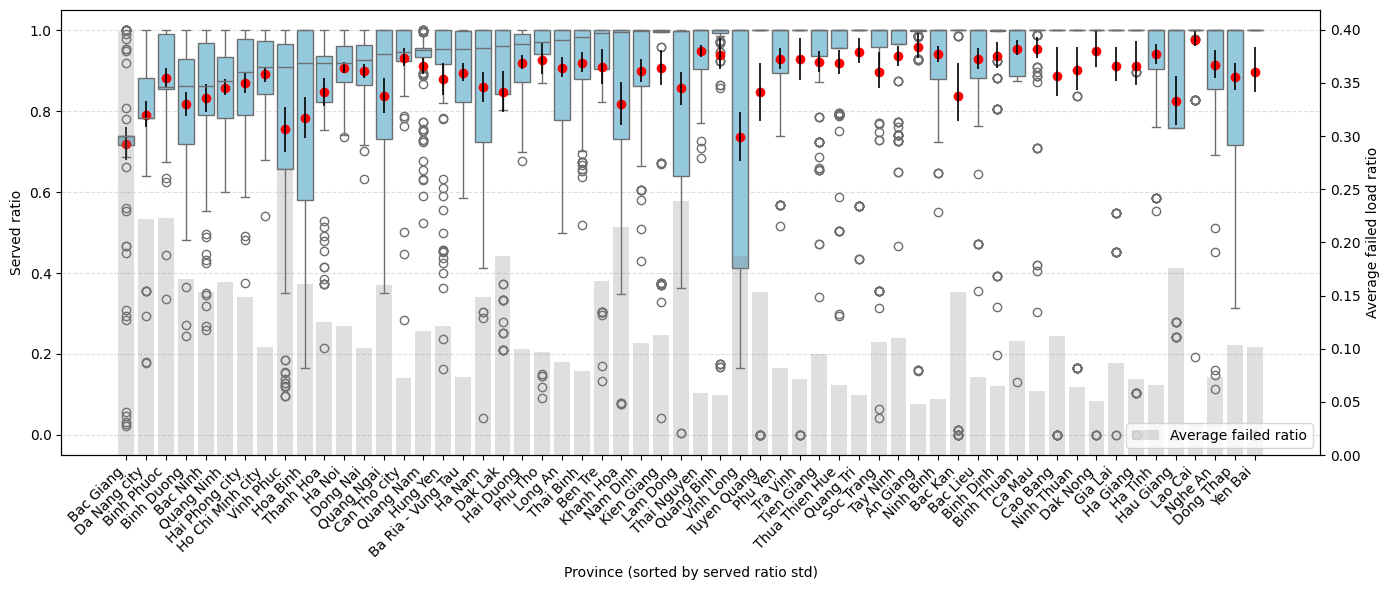

In [15]:
# OLD VERSION

# def analyze_load_served_ratio_by_adm(loads_gdf, load_status_df, results_df, net_dir, output_dir, removal_fraction=0.05):
#     # === Step 1: 读取成功迭代 ===
#     passed_iters = (
#         results_df[
#             (results_df["powerflow_success"] == True) &
#             (results_df["removal_fraction"] == removal_fraction)
#         ]["iteration"]
#         .astype(int)
#         .squeeze()
#         .tolist()
#     )
#     print(f"\u2713 Found {len(passed_iters)} successful iterations")

#     all_records = []

#     for i in passed_iters:
#         filepath = os.path.join(net_dir, f"net_results_{int(removal_fraction * 100)}%_iter{i}.xlsx")
#         try:
#             xls = pd.read_excel(filepath, sheet_name=None)
#             df_load = xls["load"]
#             df_res = xls["res_load"]
#         except Exception as e:
#             print(f"\u2717 Skipping {filepath}: {e}")
#             continue

#         df = df_load[["name", "p_mw"]].merge(
#             df_res[["p_mw"]], left_index=True, right_index=True, suffixes=("", "_res")
#         ).rename(columns={"name": "load_id", "p_mw": "p_mw", "p_mw_res": "res_p_mw"})

#         id_adm_df = loads_gdf[["osmid", "ADM1_EN"]].rename(columns={"osmid": "load_id"})
#         df = pd.merge(df, id_adm_df, on="load_id", how="left").dropna(subset=["ADM1_EN"])

#         grouped = df.groupby("ADM1_EN")[["res_p_mw", "p_mw"]].sum()
#         grouped["served_ratio"] = grouped["res_p_mw"] / grouped["p_mw"]
#         grouped["iteration"] = i
#         all_records.append(grouped.reset_index()[["ADM1_EN", "iteration", "served_ratio"]])

#     df_all = pd.concat(all_records, ignore_index=True)
#     df_std = df_all.groupby("ADM1_EN")["served_ratio"].std().reset_index(name="served_ratio_std")
#     df_min = df_all.groupby("ADM1_EN")["served_ratio"].min().reset_index(name="served_ratio_min")
#     df_unstable = df_std.merge(df_min, on="ADM1_EN")
#     df_unstable = df_unstable.sort_values(by="served_ratio_std", ascending=False).head(5)
#     print("\nTop 5 unstable provinces (by std of served_ratio):")
#     print(df_unstable)

#     # === Step 3: Prepare average failed ratio per region ===
#     id_adm_df = loads_gdf[['osmid', 'ADM1_EN']].rename(columns={'osmid': 'load_id'})
#     status_with_adm = pd.merge(load_status_df, id_adm_df, on='load_id', how='left')
#     status_with_adm['served'] = status_with_adm['served'].astype(bool)
#     status_with_adm = status_with_adm[status_with_adm['iteration'].isin(passed_iters)]

#     failure_ratio = (
#         status_with_adm
#         .groupby(['iteration', 'ADM1_EN'])['served']
#         .apply(lambda x: (~x).sum() / len(x))
#         .reset_index(name='failed_ratio')
#     )

#     avg_failed_ratio = (
#         failure_ratio
#         .groupby('ADM1_EN')['failed_ratio']
#         .mean()
#         .fillna(0)
#     )

#     # Filter provinces with failure
#     adm_with_failures = failure_ratio[failure_ratio["failed_ratio"] > 0]["ADM1_EN"].unique()
#     df_all = df_all[df_all["ADM1_EN"].isin(adm_with_failures)]
#     avg_failed_ratio = avg_failed_ratio.loc[adm_with_failures]

#     df_avg = df_all.groupby("ADM1_EN")["served_ratio"].mean().reset_index(name="served_ratio_mean")

#     # # Sort order by instability (std)
#     # sort_order = df_std[df_std["ADM1_EN"].isin(adm_with_failures)].sort_values("served_ratio_std", ascending=True)["ADM1_EN"]
    
#     # Sort order by median served_ratio
#     df_median = df_all.groupby("ADM1_EN")["served_ratio"].median().reset_index(name="served_ratio_median")
#     sort_order = df_median.sort_values("served_ratio_median")["ADM1_EN"]

#     # === Step 4: 绘图 ===
#     fig, ax1 = plt.subplots(figsize=(14, 6))

#     sns.boxplot(
#         data=df_all,
#         x="ADM1_EN",
#         y="served_ratio",
#         order=sort_order,
#         ax=ax1,
#         color="skyblue"
#     )

#     means = df_all.groupby("ADM1_EN")["served_ratio"].mean()

#     for xtick, adm1 in enumerate(sort_order):
#         group = df_all[df_all["ADM1_EN"] == adm1]["served_ratio"].values
#         if len(group) > 1:
#             ci = bootstrap((group,), np.mean, confidence_level=0.95, n_resamples=1000, method="basic")
#             ci_low, ci_high = ci.confidence_interval
#             ax1.plot(xtick, means[adm1], 'ro')
#             ax1.vlines(xtick, ci_low, ci_high, color='black', linewidth=1.2)
#         else:
#             ax1.plot(xtick, means[adm1], 'ro')

#     ax1.set_ylabel("Served ratio")
#     ax1.set_xlabel("Province (sorted by served ratio std)")
#     ax1.set_xticklabels(sort_order, rotation=45, ha="right")
#     ax1.grid(axis="y", linestyle="--", alpha=0.4)

#     # Right Y-axis: avg failed ratio
#     ax2 = ax1.twinx()
#     ax2.bar(sort_order, avg_failed_ratio.loc[sort_order].values, alpha=0.25, color="gray", label="Average failed ratio")
#     ax2.set_ylabel("Average failed load ratio")
#     ax2.legend(loc="lower right")

#     plt.tight_layout()
#     os.makedirs(output_dir, exist_ok=True)
#     plt.savefig(os.path.join(output_dir, "load_served_ratio_boxplot_by_adm1.png"), dpi=600, bbox_inches='tight')
#     plt.show()

#     return df_all, df_median, df_std, df_avg, failure_ratio, avg_failed_ratio


# df_all, df_median, df_std, df_avg, failure_ratio, avg_failed_ratio = analyze_load_served_ratio_by_adm(
#     loads_gdf = loads_gdf,
#     load_status_df = load_status_df,
#     results_df = results_df,
#     net_dir = net_dir,
#     output_dir = output_dir,
#     removal_fraction = removal_fraction
# )

✓ Found 98 successful iterations

Top 5 unstable provinces (by std of served_ratio):
        ADM1_EN  served_ratio_std  served_ratio_min
3       Bac Kan          0.369471          0.000000
54  Tuyen Quang          0.361898          0.000000
13     Cao Bang          0.317290          0.000000
57      Yen Bai          0.304258          0.000000
55    Vinh Long          0.302607          0.164227

Top 5 stable provinces (by std of served_ratio):
        ADM1_EN  served_ratio_std  served_ratio_min
22       Ha Noi          0.067542          0.735197
49  Thai Nguyen          0.082574          0.685300
17     Dong Nai          0.083137          0.632959
24    Hai Duong          0.092073          0.677649
33      Lao Cai          0.094081          0.192159


C:\Users\mye500\AppData\Local\Temp\ipykernel_9868\2994780580.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick_labels, rotation=45, ha="right")


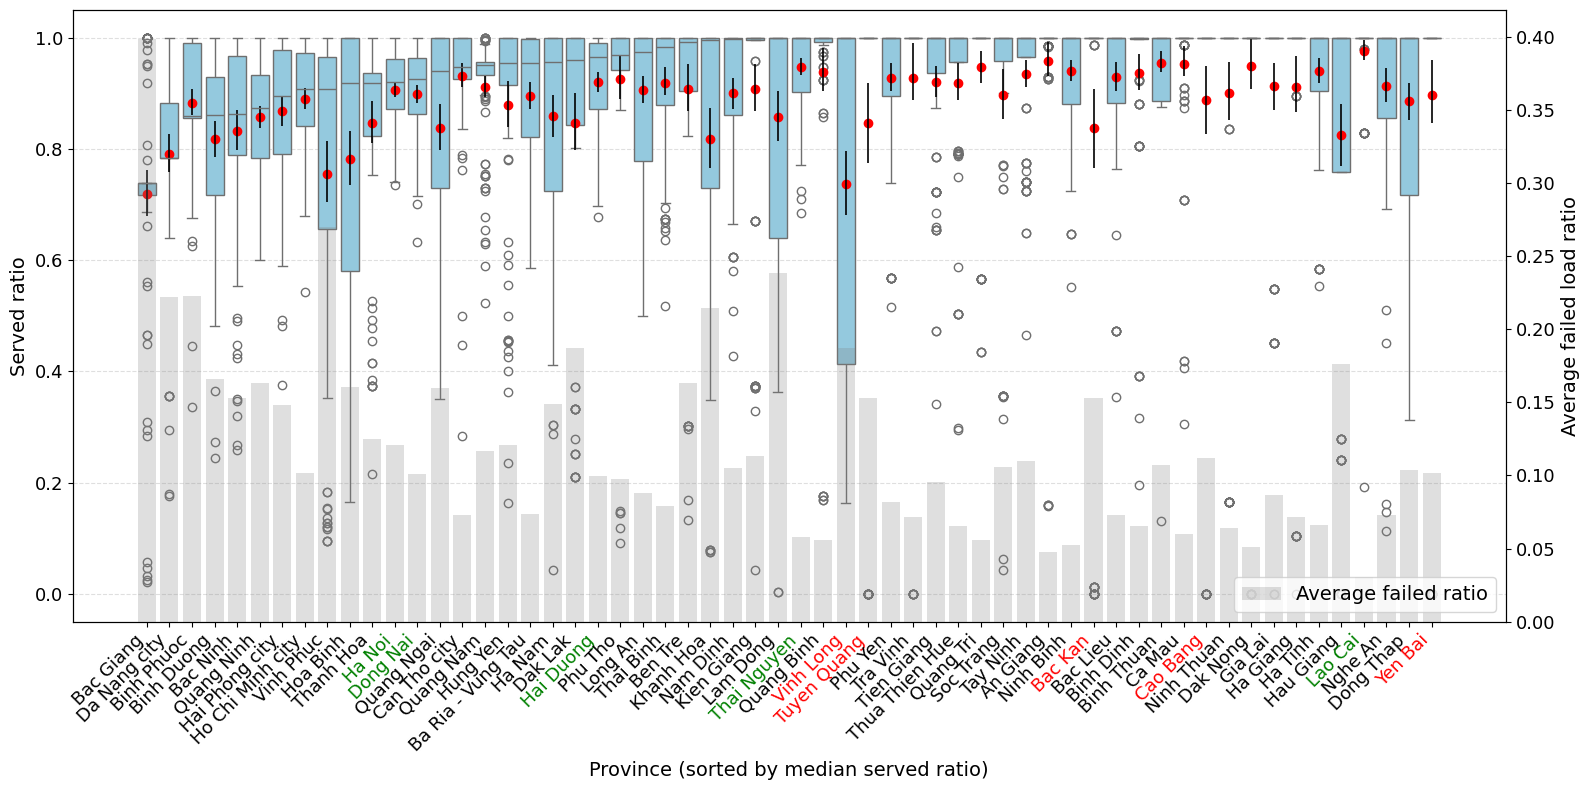

In [25]:
def analyze_load_served_ratio_by_adm(loads_gdf, load_status_df, results_df, net_dir, output_dir, removal_fraction=0.05):
    # === Step 1: 读取成功迭代 ===
    passed_iters = (
        results_df[
            (results_df["powerflow_success"] == True) &
            (results_df["removal_fraction"] == removal_fraction)
        ]["iteration"]
        .astype(int)
        .squeeze()
        .tolist()
    )
    print(f"\u2713 Found {len(passed_iters)} successful iterations")

    all_records = []

    for i in passed_iters:
        filepath = os.path.join(net_dir, f"net_results_{int(removal_fraction * 100)}%_iter{i}.xlsx")
        try:
            xls = pd.read_excel(filepath, sheet_name=None)
            df_load = xls["load"]
            df_res = xls["res_load"]
        except Exception as e:
            print(f"\u2717 Skipping {filepath}: {e}")
            continue

        df = df_load[["name", "p_mw"]].merge(
            df_res[["p_mw"]], left_index=True, right_index=True, suffixes=("", "_res")
        ).rename(columns={"name": "load_id", "p_mw": "p_mw", "p_mw_res": "res_p_mw"})

        id_adm_df = loads_gdf[["osmid", "ADM1_EN"]].rename(columns={"osmid": "load_id"})
        df = pd.merge(df, id_adm_df, on="load_id", how="left").dropna(subset=["ADM1_EN"])

        grouped = df.groupby("ADM1_EN")[["res_p_mw", "p_mw"]].sum()
        grouped["served_ratio"] = grouped["res_p_mw"] / grouped["p_mw"]
        grouped["iteration"] = i
        all_records.append(grouped.reset_index()[["ADM1_EN", "iteration", "served_ratio"]])

    df_all = pd.concat(all_records, ignore_index=True)
    df_std = df_all.groupby("ADM1_EN")["served_ratio"].std().reset_index(name="served_ratio_std")
    df_min = df_all.groupby("ADM1_EN")["served_ratio"].min().reset_index(name="served_ratio_min")

    # Unstable (high std)
    df_unstable = df_std.merge(df_min, on="ADM1_EN")
    df_unstable = df_unstable.sort_values(by="served_ratio_std", ascending=False).head(5)
    print("\nTop 5 unstable provinces (by std of served_ratio):")
    print(df_unstable)

    # Stable (low std)
    df_stable = df_std.merge(df_min, on="ADM1_EN")
    df_stable = df_stable.sort_values(by="served_ratio_std", ascending=True).head(5)
    print("\nTop 5 stable provinces (by std of served_ratio):")
    print(df_stable)

    # === Step 3: Prepare average failed ratio per region ===
    id_adm_df = loads_gdf[['osmid', 'ADM1_EN']].rename(columns={'osmid': 'load_id'})
    status_with_adm = pd.merge(load_status_df, id_adm_df, on='load_id', how='left')
    status_with_adm['served'] = status_with_adm['served'].astype(bool)
    status_with_adm = status_with_adm[status_with_adm['iteration'].isin(passed_iters)]

    failure_ratio = (
        status_with_adm
        .groupby(['iteration', 'ADM1_EN'])['served']
        .apply(lambda x: (~x).sum() / len(x))
        .reset_index(name='failed_ratio')
    )

    avg_failed_ratio = (
        failure_ratio
        .groupby('ADM1_EN')['failed_ratio']
        .mean()
        .fillna(0)
    )

    # Filter provinces with failure
    adm_with_failures = failure_ratio[failure_ratio["failed_ratio"] > 0]["ADM1_EN"].unique()
    df_all = df_all[df_all["ADM1_EN"].isin(adm_with_failures)]
    avg_failed_ratio = avg_failed_ratio.loc[adm_with_failures]

    df_avg = df_all.groupby("ADM1_EN")["served_ratio"].mean().reset_index(name="served_ratio_mean")

    # Sort order by median served_ratio
    df_median = df_all.groupby("ADM1_EN")["served_ratio"].median().reset_index(name="served_ratio_median")
    sort_order = df_median.sort_values("served_ratio_median")["ADM1_EN"]

    # === Step 4: 绘图 ===
    fig, ax1 = plt.subplots(figsize=(16, 8))

    sns.boxplot(
        data=df_all,
        x="ADM1_EN",
        y="served_ratio",
        order=sort_order,
        ax=ax1,
        color="skyblue"
    )

    means = df_all.groupby("ADM1_EN")["served_ratio"].mean()

    for xtick, adm1 in enumerate(sort_order):
        group = df_all[df_all["ADM1_EN"] == adm1]["served_ratio"].values
        if len(group) > 1:
            ci = bootstrap((group,), np.mean, confidence_level=0.95, n_resamples=1000, method="basic")
            ci_low, ci_high = ci.confidence_interval
            ax1.plot(xtick, means[adm1], 'ro')
            ax1.vlines(xtick, ci_low, ci_high, color='black', linewidth=1.2)
        else:
            ax1.plot(xtick, means[adm1], 'ro')

    # 设置 x tick label 颜色（红色为最不稳定，绿色为最稳定）
    xtick_labels = ax1.get_xticklabels()
    for label in xtick_labels:
        adm = label.get_text()
        if adm in df_unstable["ADM1_EN"].values:
            label.set_color("red")
        elif adm in df_stable["ADM1_EN"].values:
            label.set_color("green")

    ax1.set_ylabel("Served ratio", fontsize=14)
    ax1.set_xlabel("Province (sorted by median served ratio)", fontsize=14)
    ax1.set_xticklabels(xtick_labels, rotation=45, ha="right")
    ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.tick_params(axis='both', labelsize=13)

    # Right Y-axis: avg failed ratio
    ax2 = ax1.twinx()
    ax2.bar(sort_order, avg_failed_ratio.loc[sort_order].values, alpha=0.25, color="gray", label="Average failed ratio")
    ax2.set_ylabel("Average failed load ratio", fontsize=14)
    ax2.legend(loc="lower right", fontsize=14)
    ax2.tick_params(axis='both', labelsize=13)

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "load_served_ratio_boxplot_by_adm1.png"), dpi=600, bbox_inches='tight')
    plt.show()

    return df_all, df_median, df_std, df_avg, failure_ratio, avg_failed_ratio


df_all, df_median, df_std, df_avg, failure_ratio, avg_failed_ratio = analyze_load_served_ratio_by_adm(
    loads_gdf = loads_gdf,
    load_status_df = load_status_df,
    results_df = results_df,
    net_dir = net_dir,
    output_dir = output_dir,
    removal_fraction = removal_fraction
)

In [21]:
def export_summary_table(df_median, df_std, df_avg, avg_failed_ratio, loads_gdf, output_dir):
    # Convert avg_failed_ratio Series to DataFrame
    df_failed = avg_failed_ratio.reset_index().rename(columns={'failed_ratio': 'avg_failed_ratio'})

    summary_df = (
        df_median
        .merge(df_std, on='ADM1_EN', how='outer')
        .merge(df_avg, on='ADM1_EN', how='outer')
        .merge(df_failed, on='ADM1_EN', how='outer')
    )

    # 添加每省负荷数量
    load_counts = (
        loads_gdf[loads_gdf["ADM1_EN"].isin(summary_df["ADM1_EN"])]
        .groupby("ADM1_EN")["osmid"]
        .nunique()
        .reset_index()
        .rename(columns={"osmid": "number of loads"})
    )

    summary_df = summary_df.merge(load_counts, on="ADM1_EN", how="left")
    summary_df["served_ratio_mean"] = (summary_df["served_ratio_mean"] * 100).round(1)
    summary_df["avg_failed_ratio"] = (summary_df["avg_failed_ratio"] * 100).round(1)
    summary_df = summary_df.sort_values(by="served_ratio_mean", ascending=True)

    summary_df.to_excel(os.path.join(output_dir, "adm1_served_summary.xlsx"), index=False)

    return summary_df

summary_df = export_summary_table(
    df_median=df_median, 
    df_std=df_std,
    df_avg=df_avg,
    avg_failed_ratio=avg_failed_ratio,
    loads_gdf=loads_gdf,
    output_dir=output_dir
)

In [22]:
summary_df

,ADM1_EN,served_ratio_median,served_ratio_std,served_ratio_mean,avg_failed_ratio,number of loads
2,Bac Giang,0.738178,0.214063,71.9,39.9,16
55,Vinh Long,1.000000,0.302607,73.7,18.7,3
56,Vinh Phuc,0.908553,0.287903,75.5,27.0,16
28,Hoa Binh,0.918441,0.259329,78.2,16.1,4
14,Da Nang city,0.783474,0.170168,79.1,22.2,28
30,Khanh Hoa,0.996377,0.268273,81.8,21.4,7
8,Binh Duong,0.861983,0.159332,81.8,16.6,58
26,Hau Giang,1.000000,0.290920,82.5,17.6,16
5,Bac Ninh,0.862510,0.185534,83.2,15.3,30
43,Quang Ngai,0.940307,0.211840,83.7,16.0,24


In [11]:
# Update total electricity demand in second dataframe based on BusID and NodeID
def update_electricity_demand(df1, df2, variable):
    # Ensure BusID is unique, resolve conflicts by summing or taking the mean
    mapping = df1.groupby('BusID')[variable].sum()
    # Map to df2 based on Index
    df2[variable] = df2['NodeID'].map(mapping)
    return df2

In [ ]:
def plot_power_grid_map(loads_gdf, gens_gdf, nodes_gdf, lines_gdf, output_dir, basemap):
    # --- Step 1: Update demand and generation to nodes_gdf ---
    nodes_gdf = update_electricity_demand(loads_gdf, nodes_gdf, 'total_electricity_demand')
    nodes_gdf = update_electricity_demand(gens_gdf, nodes_gdf, 'electricity_generation_GWh')

    # --- Step 2: Normalize to 0-1 range ---
    nodes_gdf['normalized_electricity_generation_GWh'] = (
        (nodes_gdf['electricity_generation_GWh'] - nodes_gdf['electricity_generation_GWh'].min()) /
        (nodes_gdf['electricity_generation_GWh'].max() - nodes_gdf['electricity_generation_GWh'].min())
    )
    nodes_gdf['normalized_total_electricity_demand'] = (
        (nodes_gdf['total_electricity_demand'] - nodes_gdf['total_electricity_demand'].min()) /
        (nodes_gdf['total_electricity_demand'].max() - nodes_gdf['total_electricity_demand'].min())
    )

    print('Total electricity production: ', nodes_gdf['electricity_generation_GWh'].sum())
    print('Total electricity demand: ', nodes_gdf['total_electricity_demand'].sum())

    # --- Step 3: Reproject to WGS84 ---
    nodes_gdf_plot = nodes_gdf.to_crs(epsg=4326)
    lines_gdf_plot = lines_gdf.to_crs(epsg=4326)
    basemap = basemap.to_crs(epsg=4326)

    # --- Step 5: Create figure ---
    fig, ax = plt.subplots(figsize=(6, 10))

    # --- Step 6: Plot nodes ---
    for idx, row in nodes_gdf_plot.iterrows():
        if pd.notna(row['electricity_generation_GWh']):
            ax.plot(row.geometry.x, row.geometry.y, 'bo',
                    markersize=row['normalized_electricity_generation_GWh'] * 50, alpha=0.3, markeredgewidth=0)
        elif pd.notna(row['total_electricity_demand']):
            ax.plot(row.geometry.x, row.geometry.y, 'go',
                    markersize=row['normalized_total_electricity_demand'] * 50, alpha=0.3, markeredgewidth=0)

    # --- Step 7: Plot transmission lines ---
    for idx, row in lines_gdf_plot.iterrows():
        if row['voltage'] == 500.0:
            color = '#B54EB2'; zorder = 3
        elif row['voltage'] == 220.0:
            color = '#C73030'; zorder = 2
        elif row['voltage'] == 110.0:
            color = '#B7A115'; zorder = 1
        else:
            color = 'black'; zorder = 0
        ax.plot(*row.geometry.xy, color=color, zorder=zorder, linewidth=0.6)

    # --- Step 8: Plot basemap ---
    basemap.plot(ax=ax, color='#EBEBEB', edgecolor='white', linewidth=0.3, zorder=0)

    # --- Step 9: Decorate plot ---
    ax.set_title("Vietnamese Power Grid", fontsize=9)
    ax.set_xlabel("Longitude [°]", fontsize=9)
    ax.set_ylabel("Latitude [°]", fontsize=9)
    ax.set_xlim(102, 110)
    ax.set_ylim(8, 24)
    ax.tick_params(axis='both', which='major', labelsize=8)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markersize=5, alpha=0.6, label='Cluster of generators'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='g', markersize=5, alpha=0.6, label='Cluster of loads'),
        Line2D([0], [0], color='#B54EB2', lw=1, label='500kV Line'),
        Line2D([0], [0], color='#C73030', lw=1, label='220kV Line'),
        Line2D([0], [0], color='#B7A115', lw=1, label='110kV Line')
    ]
    ax.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0.05, 0.25), fontsize=9)

    # --- Step 10: Save output ---
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, "vietnamese_power_grid.png")
    plt.savefig(output_path, dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()


Total electricity production:  276440.00000000006
Total electricity demand:  116589.09085071349


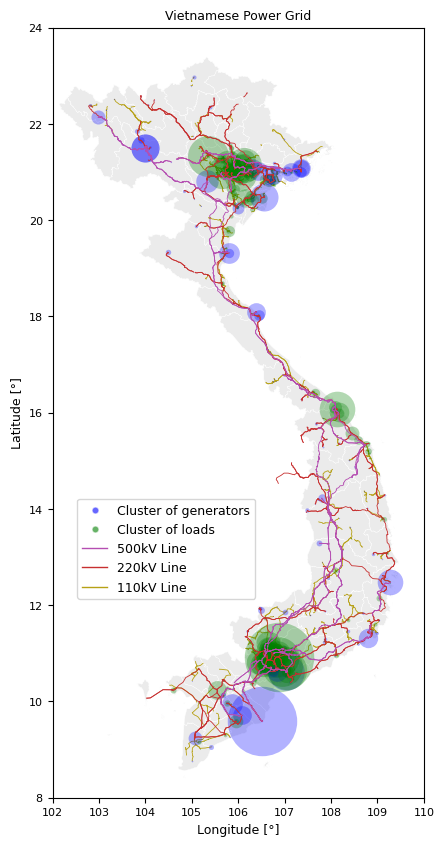

In [ ]:
plot_power_grid_map(
    loads_gdf, gens_gdf, nodes_gdf, lines_gdf,
    output_dir=output_dir, basemap=basemap)

✓ Found 98 successful iterations


C:\Users\mye500\AppData\Local\Temp\ipykernel_9868\3212052145.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(median_order, rotation=45, ha="right")


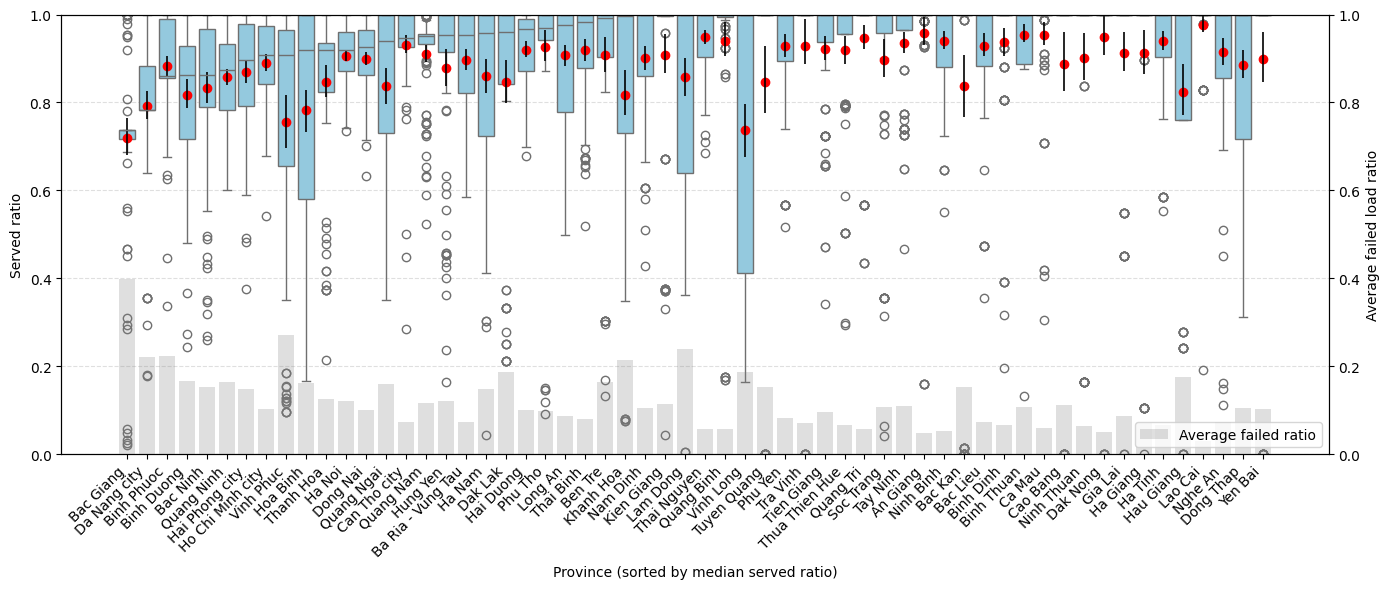

In [8]:
# OLD VERSION

# def analyze_load_served_ratio_by_adm(loads_gdf, load_status_df, results_df, net_dir, output_dir, removal_fraction=0.05):
#     # === Step 1: 读取成功迭代 ===
#     passed_iters = (
#         results_df[
#             (results_df["powerflow_success"] == True) &
#             (results_df["removal_fraction"] == removal_fraction)
#         ]["iteration"]
#         .astype(int)
#         .squeeze()
#         .tolist()
#     )
#     print(f"✓ Found {len(passed_iters)} successful iterations")

#     all_records = []

#     for i in passed_iters:
#         filepath = os.path.join(net_dir, f"net_results_{int(removal_fraction * 100)}%_iter{i}.xlsx")
#         try:
#             xls = pd.read_excel(filepath, sheet_name=None)
#             df_load = xls["load"]
#             df_res = xls["res_load"]
#         except Exception as e:
#             print(f"✗ Skipping {filepath}: {e}")
#             continue

#         df = df_load[["name", "p_mw"]].merge(
#             df_res[["p_mw"]], left_index=True, right_index=True, suffixes=("", "_res")
#         ).rename(columns={"name": "load_id", "p_mw": "p_mw", "p_mw_res": "res_p_mw"})

#         # Merge ADM1
#         id_adm_df = loads_gdf[["osmid", "ADM1_EN"]].rename(columns={"osmid": "load_id"})
#         df = pd.merge(df, id_adm_df, on="load_id", how="left").dropna(subset=["ADM1_EN"])

#         grouped = df.groupby("ADM1_EN")[["res_p_mw", "p_mw"]].sum()
#         grouped["served_ratio"] = grouped["res_p_mw"] / grouped["p_mw"]
#         grouped["iteration"] = i
#         all_records.append(grouped.reset_index()[["ADM1_EN", "iteration", "served_ratio"]])

#     df_all = pd.concat(all_records, ignore_index=True)
#     df_avg = df_all.groupby("ADM1_EN")["served_ratio"].mean().reset_index(name="served_ratio_mean")
#     df_median = df_all.groupby("ADM1_EN")["served_ratio"].median().reset_index(name="served_ratio_median")
#     median_order = df_median.sort_values(by="served_ratio_median", ascending=True)["ADM1_EN"]

#     # === Step 3: Prepare average failed ratio per region ===
#     id_adm_df = loads_gdf[['osmid', 'ADM1_EN']].rename(columns={'osmid': 'load_id'})
#     status_with_adm = pd.merge(load_status_df, id_adm_df, on='load_id', how='left')
#     status_with_adm['served'] = status_with_adm['served'].astype(bool)
#     status_with_adm = status_with_adm[status_with_adm['iteration'].isin(passed_iters)]

#     failure_ratio = (
#         status_with_adm
#         .groupby(['iteration', 'ADM1_EN'])['served']
#         .apply(lambda x: (~x).sum() / len(x))
#         .reset_index(name='failed_ratio')
#     )

#     avg_failed_ratio = (
#         failure_ratio
#         .groupby('ADM1_EN')['failed_ratio']
#         .mean()
#         .reindex(median_order)
#         .fillna(0)
#     )

#     # 仅保留有 failed load 的 ADM1
#     adm_with_failures = failure_ratio[failure_ratio["failed_ratio"] > 0]["ADM1_EN"].unique()
#     df_all = df_all[df_all["ADM1_EN"].isin(adm_with_failures)]
#     df_avg = df_avg[df_avg["ADM1_EN"].isin(adm_with_failures)]
#     median_order = df_median.sort_values(by="served_ratio_median", ascending=True)["ADM1_EN"]
#     avg_failed_ratio = avg_failed_ratio.loc[median_order]

#     # === Step 4: 绘图 ===
#     fig, ax1 = plt.subplots(figsize=(14, 6))

#     sns.boxplot(
#         data=df_all,
#         x="ADM1_EN",
#         y="served_ratio",
#         order=median_order,
#         ax=ax1,
#         color="skyblue"
#     )

#     means = df_all.groupby("ADM1_EN")["served_ratio"].mean()

#     for xtick, adm1 in enumerate(median_order):
#         group = df_all[df_all["ADM1_EN"] == adm1]["served_ratio"].values
#         if len(group) > 1:
#             ci = bootstrap((group,), np.mean, confidence_level=0.95, n_resamples=1000, method="basic")
#             ci_low, ci_high = ci.confidence_interval
#             ax1.plot(xtick, means[adm1], 'ro')
#             ax1.vlines(xtick, ci_low, ci_high, color='black', linewidth=1.2)
#         else:
#             ax1.plot(xtick, means[adm1], 'ro')

#     # global_median = df_all["served_ratio"].median()
#     # ax1.axhline(global_median, color="green", linestyle="--", linewidth=1.2, label="Global median")
#     ax1.set_ylabel("Served ratio")
#     ax1.set_xlabel("Province (sorted by median served ratio)")
#     ax1.set_xticklabels(median_order, rotation=45, ha="right")
#     ax1.grid(axis="y", linestyle="--", alpha=0.4)
#     # ax1.set_ylim(0, 1)
#     # ax1.legend(loc="upper left")

#     # 替换右轴为平均失败比例
#     ax2 = ax1.twinx()
#     ax2.bar(median_order, avg_failed_ratio.values, alpha=0.25, color="gray", label="Average failed ratio")
#     ax2.set_ylabel("Average failed load ratio")
#     # ax2.set_ylim(0, 1)
#     ax2.legend(loc="lower right")

#     plt.tight_layout()
#     os.makedirs(output_dir, exist_ok=True)
#     plt.savefig(os.path.join(output_dir, "load_served_ratio_boxplot_by_adm1.png"), dpi=600, bbox_inches='tight')
#     plt.show()

#     return df_all, df_avg, failure_ratio, avg_failed_ratio


# df_all, df_avg, failure_ratio, avg_failed_ratio = analyze_load_served_ratio_by_adm(
#     loads_gdf = loads_gdf,
#     load_status_df = load_status_df,
#     results_df = results_df,
#     net_dir = net_dir,
#     output_dir = output_dir,
#     removal_fraction = removal_fraction
# )

In [ ]:
# # OLD VERSION
# def analyze_overloaded_lines(overload_lines_df, lines_gdf, threshold = 0.5, output_dir=None):
#     os.makedirs(output_dir, exist_ok=True)
    
#     # === Step 1: 统计每条线路超载次数 ===
#     overload_count = overload_lines_df.groupby("line_name").size().rename("overload_count").reset_index()
    
#     # 从 overload_lines_df 提取所有唯一的仿真组合
#     sim_combinations = overload_lines_df[["removal_fraction", "iteration"]].drop_duplicates()
#     # 真实参与仿真的总次数（成功且线路有结果）
#     num_simulations = sim_combinations.shape[0]

#     overload_count["overload_ratio"] = overload_count["overload_count"] / num_simulations
#     overload_count = overload_count.sort_values("overload_ratio", ascending=False)

#     # 保存统计表
#     overload_count.to_csv(os.path.join(output_dir, "overloaded_line_stats.csv"))

#     # === Step 2: 关键线路筛选 ===
#     critical_lines = overload_count[overload_count["overload_ratio"] >= threshold]
#     critical_lines.to_csv(os.path.join(output_dir, f"critical_lines_over_{int(threshold*100)}pct.csv"))

#     # === Step 3a: 可视化柱状图 ===
#     plt.figure(figsize=(8, 6))
#     top_lines = overload_count.head(10)
#     plt.bar(top_lines["line_name"], top_lines["overload_ratio"], color="tomato")
#     plt.ylabel("Overload frequency")
#     plt.xlabel("LineID (Top 10)")
#     plt.title("Top 10 line overload ratios")
#     plt.tight_layout()
#     plt.savefig(os.path.join(output_dir, "overload_bar_top10.png"), dpi=300)
#     plt.show()
#     plt.close()

#     # === Step 3b: 地图可视化 ===
#     lines_with_ratio = lines_gdf.merge(overload_count, how="left", left_on="LineID", right_on="line_name")
#     lines_with_ratio["overload_ratio"] = lines_with_ratio["overload_ratio"].fillna(0)

#     fig, ax = plt.subplots(1, 1, figsize=(12, 10))
#     lines_with_ratio.plot(column="overload_ratio", cmap="Reds", legend=True,
#                           linewidth=1, ax=ax)
#     ax.set_title("Line overload frequency map", fontsize=15)
#     plt.axis("off")
#     plt.savefig(os.path.join(output_dir, "overload_map.png"), dpi=300)
#     plt.show()
#     plt.close()

#     # === Step 4: 过载率 vs 线路长度 ===
#     if "Length" in lines_with_ratio.columns:
#         plt.figure(figsize=(8, 6))
#         plt.scatter(lines_with_ratio["Length"], lines_with_ratio["overload_ratio"], alpha=0.6)
#         plt.xlabel("Line Length (km)")
#         plt.ylabel("Overload Ratio")
#         plt.title("Overload Ratio vs. Line Length")
#         plt.grid(True)
#         plt.tight_layout()
#         plt.savefig(os.path.join(output_dir, "overload_vs_length.png"), dpi=300)
#         plt.show()

#     # === Step 5: 区域统计（如有）===
#     region_field = "ADM1_EN" if "ADM1_EN" in lines_with_ratio.columns else None
#     if region_field:
#         region_critical = lines_with_ratio[lines_with_ratio["overload_ratio"] >= threshold]
#         region_summary = region_critical.groupby(region_field).size().rename("critical_line_count").reset_index()
#         region_summary.to_csv(os.path.join(output_dir, "critical_line_count_by_region.csv"), index=False)

#     # === Step 6: Histogram of overload ratio bins (vs. total lines) ===
#     bins = np.arange(0.01, 1.01, 0.1)
#     lines_with_ratio["overload_ratio"] = lines_with_ratio["overload_ratio"].fillna(0)

#     total_lines_all = len(lines_with_ratio)
#     lines_positive = lines_with_ratio[lines_with_ratio["overload_ratio"] > 0]

#     counts, bin_edges = np.histogram(lines_positive["overload_ratio"], bins=bins)
#     bin_labels = [f"{round(bin_edges[i],1)}–{round(bin_edges[i+1],1)}" for i in range(len(counts))]
#     proportions = [f"{(c/total_lines_all*100):.2f}%" for c in counts]

#     plt.figure(figsize=(9, 6))
#     bars = plt.bar(bin_labels, counts, color="skyblue", edgecolor="lightgray")
#     plt.xlabel("Overload ratio interval (excl. 0)", fontsize=12)
#     plt.ylabel("Number of lines", fontsize=12)
#     plt.title("Overload ratio distribution (% of all lines)", fontsize=14)
#     plt.grid(axis="y", linestyle="--", alpha=0.7)

#     for bar, pct in zip(bars, proportions):
#         height = bar.get_height()
#         plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, pct,
#                  ha="center", va="bottom", fontsize=10, fontweight="bold")

#     plt.tight_layout()
#     plt.savefig(os.path.join(output_dir, "overload_ratio_hist_vs_all_lines.png"), dpi=300)
#     plt.show()


#     return overload_count, critical_lines, lines_with_ratio


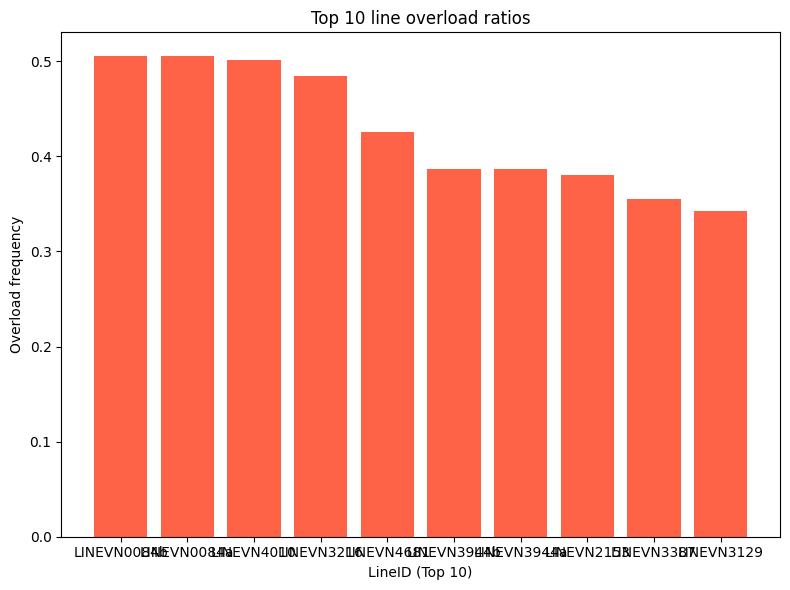

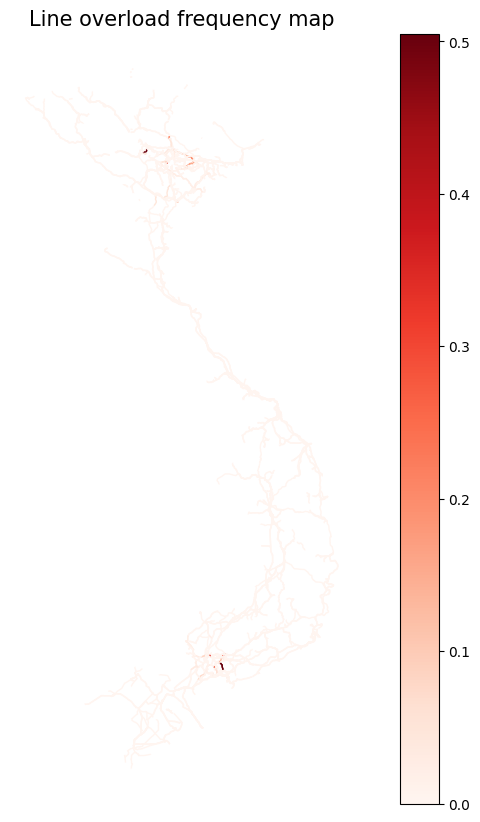

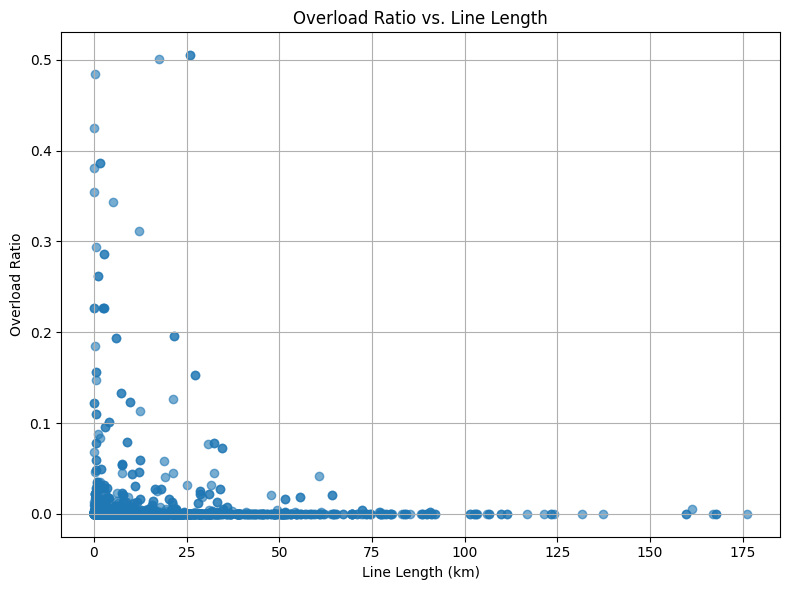

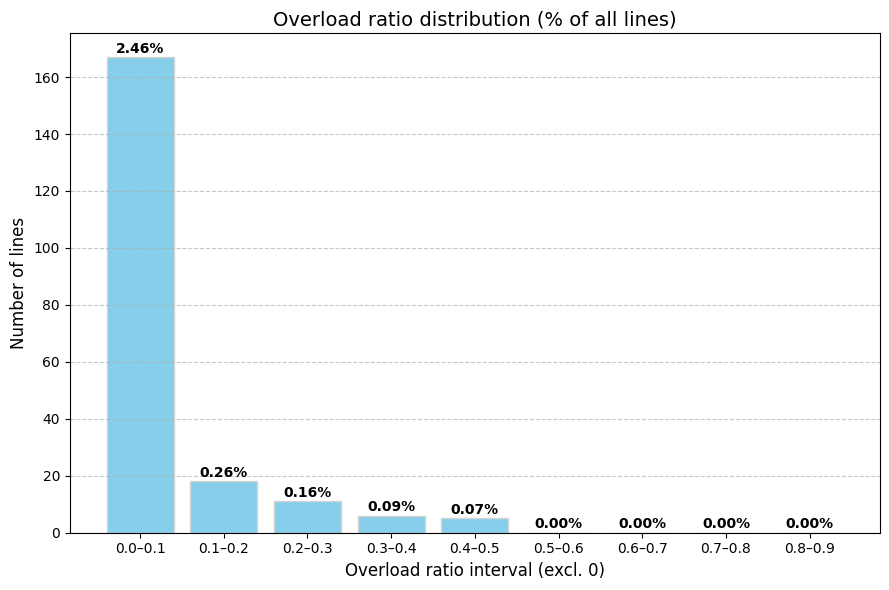

In [ ]:
# overload_count, critical_lines, lines_with_ratio = analyze_overloaded_lines(overload_lines_df, lines_gdf, threshold=0.5, output_dir=output_dir)

In [ ]:
# # OLD VERSION
# def plot_overload_ratio_maps_by_region(lines_with_ratio, output_dir=None, basemap=None):
#     os.makedirs(output_dir, exist_ok=True)

#     # 统一坐标系
#     lines_with_ratio = lines_with_ratio.to_crs("EPSG:4326")
#     basemap = basemap.to_crs("EPSG:4326")

#     # 区域定义
#     pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104',
#                   'VN717','VN711','VN707','VN713','VN701','VN709']
#     target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
#     other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

#     # 统一色阶
#     vmin = lines_with_ratio["overload_ratio"].min()
#     vmax = lines_with_ratio["overload_ratio"].max()
#     norm = colors.Normalize(vmin=vmin, vmax=vmax)
#     cmap = plt.colormaps.get_cmap("Blues")

#     overloaded = lines_with_ratio[lines_with_ratio["overload_ratio"] > 0]
#     non_overloaded = lines_with_ratio[lines_with_ratio["overload_ratio"] == 0]
    
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

#     # 子图 1：Red River Delta
#     ax1.set_title("Red River Delta", fontsize=15)
#     ax1.set_xlabel("Longitude", fontsize=15)
#     ax1.set_ylabel("Latitude", fontsize=15)
#     ax1.set_xlim(105, 107.25)
#     ax1.set_ylim(19.75, 21.75)
#     ax1.set_aspect('auto')
#     ax1.tick_params(axis='both', labelsize=14)
#     target_regions.plot(ax=ax1, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
#     other_regions.plot(ax=ax1, color='white', edgecolor='lightgray', linewidth=0.5, zorder=2)
#     non_overloaded.plot(ax=ax1, color='lightgreen', linewidth=0.5, zorder=3)
#     overloaded.plot(ax=ax1, column="overload_ratio", cmap=cmap, norm=norm, linewidth=1, zorder=4)

#     # lines_with_ratio.plot(ax=ax1, column="overload_ratio", cmap=cmap, norm=norm, linewidth=1.5, legend=False, zorder=3)

#     # 子图 2：Southeast
#     ax2.set_title("Southeast Region", fontsize=15)
#     ax2.set_xlabel("Longitude", fontsize=15)
#     ax2.set_xlim(105.5, 108)
#     ax2.set_ylim(10.25, 12.5)
#     ax2.set_aspect('auto')
#     ax2.tick_params(axis='both', labelsize=14)
#     target_regions.plot(ax=ax2, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
#     other_regions.plot(ax=ax2, color='white', edgecolor='lightgray', linewidth=0.5, zorder=2)
#     non_overloaded.plot(ax=ax2, color='lightgreen', linewidth=0.5, zorder=3)
#     overloaded.plot(ax=ax2, column="overload_ratio", cmap=cmap, norm=norm, linewidth=1, zorder=4)

#     # lines_with_ratio.plot(ax=ax2, column="overload_ratio", cmap=cmap, norm=norm, linewidth=1.5, legend=False, zorder=3)

#     # 色条
#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm._A = []
#     cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation="vertical", location='right', fraction=0.02)
#     cbar.set_label("Overload Ratio", fontsize=15)

#     plt.savefig(os.path.join(output_dir, "overload_map_region_split.png"), dpi=600, bbox_inches="tight")
#     plt.show(fig)

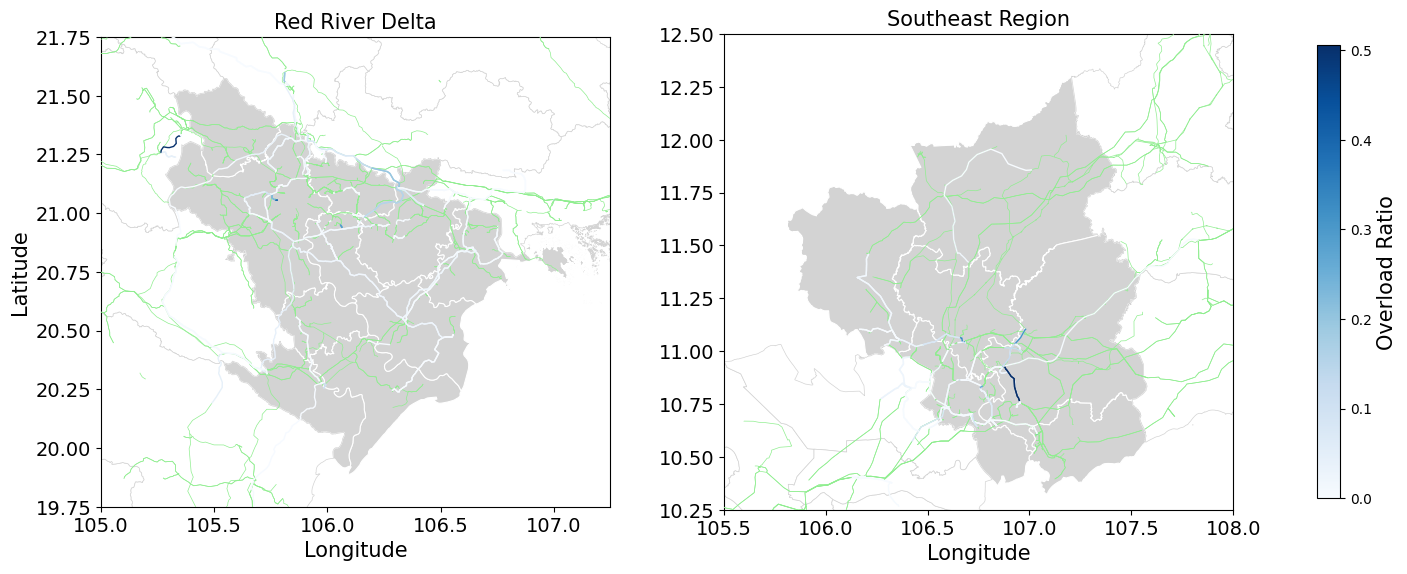

In [16]:
# plot_overload_ratio_maps_by_region(lines_with_ratio, output_dir=output_dir, basemap=basemap)